In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/diabetes_clustered.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cluster,risk_category
0,6.0,148.0,72.0,35.0,264.8,33.6,0.627,50.0,0,high risk
1,1.0,85.0,66.0,29.0,65.2,26.6,0.351,31.0,1,low risk
2,8.0,183.0,64.0,30.6,198.2,23.3,0.672,32.0,0,high risk
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,1,low risk
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,0,high risk


In [3]:
df.shape

(768, 10)

In [4]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Cluster                     0
risk_category               0
dtype: int64

In [5]:
features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age']

X = df[features]
y = df['Cluster']

print(X.shape, y.shape)
X.head()


(768, 7) (768,)


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148.0,72.0,35.0,264.8,33.6,0.627,50.0
1,85.0,66.0,29.0,65.2,26.6,0.351,31.0
2,183.0,64.0,30.6,198.2,23.3,0.672,32.0
3,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,137.0,40.0,35.0,168.0,43.1,2.288,33.0


In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    random_state=42,test_size=0.2,stratify=y
    )

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(614, 7) (154, 7)
Cluster
1    346
0    268
Name: count, dtype: int64
Cluster
1    87
0    67
Name: count, dtype: int64


In [7]:
from src.preprocessing import scale_column

X_train_scaled, scaler = scale_column(X_train, features)
X_test_scaled = X_test.copy()
X_test_scaled[features] = scaler.transform(X_test[features])

In [8]:
from sklearn.linear_model import LogisticRegression


model_logistic = LogisticRegression(random_state=42)
model_logistic.fit(X_train_scaled[features], y_train)
y_predect = model_logistic.predict(X_test_scaled[features])



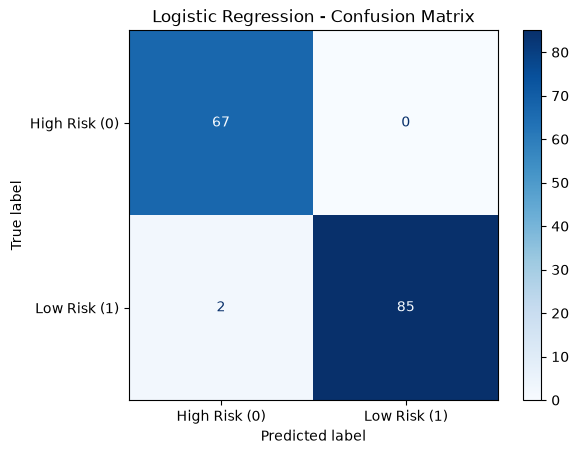

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_predect)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["High Risk (0)", "Low Risk (1)"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

True positive = 67, false negative = 0
false positive = 2, true negative = 85

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predect, target_names=["High Risk (0)", "Low Risk (1)"]))

               precision    recall  f1-score   support

High Risk (0)       0.97      1.00      0.99        67
 Low Risk (1)       1.00      0.98      0.99        87

     accuracy                           0.99       154
    macro avg       0.99      0.99      0.99       154
 weighted avg       0.99      0.99      0.99       154



In [11]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_scaled[features],y_train)
y_predect_rf = model_rf.predict(X_test_scaled[features])
    

In [15]:
cm_rf = confusion_matrix(y_test, y_predect_rf)
print(cm_rf)

[[65  2]
 [ 7 80]]


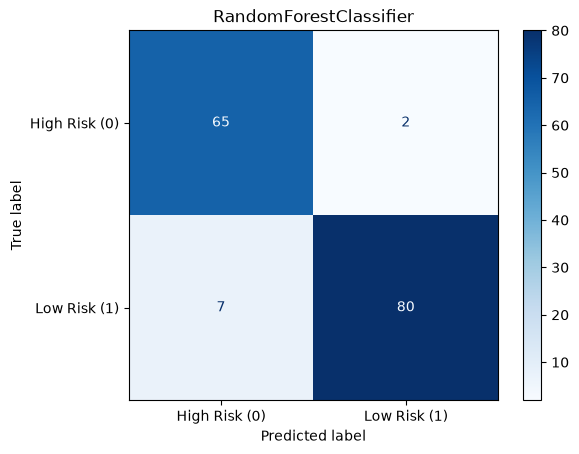

In [16]:

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["High Risk (0)", "Low Risk (1)"])
disp.plot(cmap="Blues")
plt.title("RandomForestClassifier")
plt.show()

In [17]:
print(classification_report(y_test, y_predect_rf, target_names=["High Risk (0)", "Low Risk (1)"]))

               precision    recall  f1-score   support

High Risk (0)       0.90      0.97      0.94        67
 Low Risk (1)       0.98      0.92      0.95        87

     accuracy                           0.94       154
    macro avg       0.94      0.94      0.94       154
 weighted avg       0.94      0.94      0.94       154



In [18]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train_scaled[features], y_train)

y_pred_gb = model_gb.predict(X_test_scaled[features])

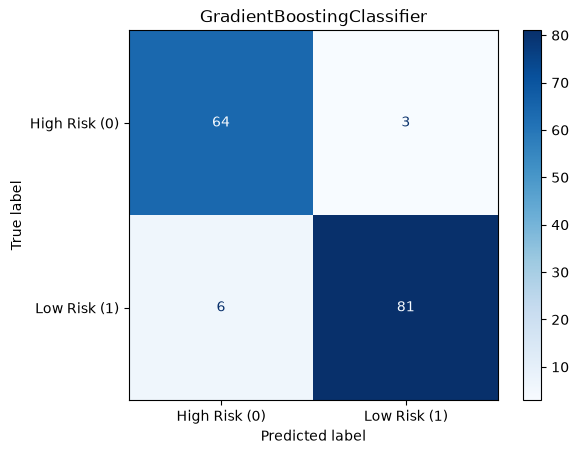

In [19]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=["High Risk (0)", "Low Risk (1)"])
disp.plot(cmap="Blues")
plt.title("GradientBoostingClassifier")
plt.show()

In [20]:
print(cm_gb)

[[64  3]
 [ 6 81]]


True Posive = 64
False Negative = 3
False Positive  = 6
True negative = 81

In [21]:
print(classification_report(y_test, y_pred_gb, target_names=["High Risk (0)", "Low Risk (1)"]))

               precision    recall  f1-score   support

High Risk (0)       0.91      0.96      0.93        67
 Low Risk (1)       0.96      0.93      0.95        87

     accuracy                           0.94       154
    macro avg       0.94      0.94      0.94       154
 weighted avg       0.94      0.94      0.94       154



In [30]:
from sklearn.model_selection import GridSearchCV

param_grid_logistic = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

grid_logistic = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_logistic,
    cv=5,
    scoring="f1"
)
grid_logistic.fit(X_train_scaled[features], y_train)

print(grid_logistic.best_params_)
print(grid_logistic.best_score_)

{'C': 10, 'solver': 'lbfgs'}
0.992846865364851


In [31]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="f1"
)
grid_rf.fit(X_train_scaled[features], y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
0.9613410128767821


In [32]:
param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring="f1"
)
grid_gb.fit(X_train_scaled[features], y_train)

print(grid_gb.best_params_)
print(grid_gb.best_score_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
0.9572202783024736


In [34]:
best_model_logistic = grid_logistic.best_estimator_
y_pred_logistic_tuned = best_model_logistic.predict(X_test_scaled[features])

cm_logistic_tuned = confusion_matrix(y_test, y_pred_logistic_tuned)
print(cm_logistic_tuned)

[[67  0]
 [ 2 85]]


In [35]:
best_model_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_model_rf.predict(X_test_scaled[features])

cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
print(cm_rf_tuned)

[[63  4]
 [10 77]]


In [36]:
best_model_gb = grid_gb.best_estimator_
y_pred_gb_tuned = best_model_gb.predict(X_test_scaled[features])

cm_gb_tuned = confusion_matrix(y_test, y_pred_gb_tuned)
print(cm_gb_tuned)


[[64  3]
 [ 6 81]]


# Step 5 — Model Comparison Results

Target: `Cluster` (0 = High Risk, 1 = Low Risk), from K-Means (k=2)
Features: Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
Test set: 154 patients (67 High Risk, 87 Low Risk)

## 1. Logistic Regression

**Before tuning**
- Confusion Matrix: [[67, 0], [2, 85]]
- Precision (High Risk): 0.97 | Recall: 1.00 | F1: 0.99
- Accuracy: 0.99
- Missed high-risk patients (False Negatives): 0

**After tuning** (GridSearchCV, best params: C=10, solver=lbfgs)
- Confusion Matrix: [[67, 0], [2, 85]] — same as untuned
- CV F1 score during search: 0.993

**Verdict:** Best model overall, by a clear margin. Zero missed high-risk cases, fewest total errors (2/154). Tuning did not change test performance.

## 2. Random Forest

**Before tuning**
- Confusion Matrix: [[65, 2], [7, 80]]
- Precision: 0.90 | Recall: 0.97 | F1: 0.94
- Accuracy: 0.94
- Missed high-risk patients: 2

**After tuning** (max_depth=5, min_samples_split=5, n_estimators=100)
- Confusion Matrix: [[63, 4], [10, 77]]
- Missed high-risk patients: 4 (worse than untuned)
- CV F1 score during search: 0.961

**Verdict:** Tuning slightly hurt test performance, likely due to cross-validation not fully generalizing on a small dataset. Untuned version was better.

## 3. Gradient Boosting

**Before tuning**
- Confusion Matrix: [[64, 3], [6, 81]]
- Precision: 0.91 | Recall: 0.96 | F1: 0.93
- Accuracy: 0.94
- Missed high-risk patients: 3

**After tuning** (learning_rate=0.1, max_depth=3, n_estimators=100)
- Confusion Matrix: [[64, 3], [6, 81]] — same as untuned
- CV F1 score during search: 0.957

**Verdict:** No change from tuning. Solid but behind Logistic Regression.

## Final Decision

**Selected model: Logistic Regression** (C=10, solver='lbfgs')

Reasons:
- Best score on every metric across all 6 tested variants (3 models × tuned/untuned)
- Zero false negatives — no high-risk patient missed, the most important property for a medical screening tool
- Performance stable and consistent, not dependent on tuning

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=10, solver="lbfgs", random_state=42, max_iter=1000))
])

In [39]:
final_pipeline.fit(X_train[features], y_train)
y_pred_pipeline = final_pipeline.predict(X_test[features])

cm_pipeline = confusion_matrix(y_test, y_pred_pipeline)
print(cm_pipeline)

[[67  0]
 [ 2 85]]


In [40]:
import joblib

joblib.dump(final_pipeline, "../models/diabetes_risk_pipeline.joblib")

['../models/diabetes_risk_pipeline.joblib']

In [41]:
loaded_pipeline = joblib.load("../models/diabetes_risk_pipeline.joblib")

trained_model = loaded_pipeline.named_steps["model"]
print(trained_model.coef_)
print(trained_model.intercept_)

[[-6.75906095 -4.64542667 -3.84067345 -7.1989886  -4.44156516 -1.17908273
  -5.37167561]]
[2.15788396]
